# EDS API — Volume-Equivalent (VE) Production Fetcher

This notebook demonstrates `fetcher_ve.py`, which solves a normalization problem in renewable energy analysis: **raw production grows over time simply because capacity grows**. To isolate the underlying weather/irradiance signal you need to deflate production by installed capacity.

In [1]:
!pip install ET-eds-api --upgrade --quiet

from ET_eds_api import get_wp_h, wagg_wp, VE, columns

---

## The Problem: Capacity Growth Obscures the Weather Signal

If solar capacity doubles over two years, raw `SolarMWh` will trend upward even in identical weather conditions. Comparing January 2023 to January 2025 production directly is misleading.

The fix is a **capacity index**: express each month's installed capacity relative to a fixed reference point (here: the most recent month), then divide production by that index. The result is production *as if capacity had always been at its current level* — a weather-comparable series.

The fetcher pulls from two EDS datasets:

| Dataset | Granularity | Used for |
|---|---|---|
| [`ProductionConsumptionSettlement`](https://www.energidataservice.dk/tso-electricity/ProductionConsumptionSettlement) | Hourly, by price area | Raw production (MWh) |
| [`CapacityPerMunicipality`](https://www.energidataservice.dk/tso-electricity/CapacityPerMunicipality) | Monthly, by municipality | Installed capacity (MW) |

---

## Exploring available columns

Not sure what to pass? `columns()` fetches one row from each dataset and prints the options, filtered to production (`_MWh`) and capacity columns.

In [2]:
columns()

── value_columns (ProductionConsumptionSettlement) ──
  OffshoreWindLt100MW_MWh
  OffshoreWindGe100MW_MWh
  OnshoreWindLt50kW_MWh
  OnshoreWindGe50kW_MWh
  SolarPowerLt10kW_MWh
  SolarPowerGe10Lt40kW_MWh
  SolarPowerGe40kW_MWh
  ExchangeNO_MWh
  ExchangeSE_MWh
  ExchangeGE_MWh
  ExchangeNL_MWh
  ExchangeGB_MWh
  ExchangeGreatBelt_MWh

── cap_column (CapacityPerMunicipality) ──
  CapacityGe100MW
  CapacityLt100MW
  OffshoreWindCapacity
  OnshoreWindCapacity
  SolarPowerCapacity


---

## Example: Solar VE

We pass:
- `value_columns` — which production columns to sum (note that there are often multiple to get aggreget solar or the like)
- `cap_column` — the capacity column to build the index from
- `col_name` — name for the deflated output column

In [3]:
solar_ve = VE(
    value_columns = ["SolarPowerLt10kW_MWh", "SolarPowerGe10Lt40kW_MWh", "SolarPowerGe40kW_MWh"],
    cap_column    = ["SolarPowerCapacity"],
    col_name      = "solar_VE",
    start         = 2022,
    end           = 2026,
    cache         = True,
)

solar_ve.head()


Index denominator is: ===================

  SolarPowerCapacity: 3528.93331  (last observed)


,HourUTC,month,value,solar_VE_idx,solar_VE
0,2022-01-01 00:00:00,2022-01-01,0.039447,0.454633,0.086767
1,2022-01-01 01:00:00,2022-01-01,0.038355,0.454633,0.084365
2,2022-01-01 02:00:00,2022-01-01,0.040499,0.454633,0.089081
3,2022-01-01 03:00:00,2022-01-01,0.038617,0.454633,0.084941
4,2022-01-01 04:00:00,2022-01-01,0.034393,0.454633,0.075650


The output contains:
- `value` — raw hourly production (MWh), summed across price areas
- `solar_VE_idx` — capacity index for that month (relative to the last month in the series)
- `solar_VE` — deflated production = `value / solar_VE_idx`

An index of 0.8 in a given month means capacity was 80% of today's level → production is scaled *up* by 1/0.8 to make it comparable.

### Sanity check: `no_index=True`

Setting `no_index=True` forces the index to 1 everywhere, so `solar_ve == value`. Useful to verify the raw series before applying deflation.

In [4]:
solar_raw = VE(
    value_columns = ["SolarPowerLt10kW_MWh", "SolarPowerGe10Lt40kW_MWh", "SolarPowerGe40kW_MWh"],
    cap_column    = ["SolarPowerCapacity"],
    col_name      = "solar_VE",
    start         = 2022,
    end           = 2026,
    no_index      = True,
    verbose       = False,
    cache         = True,
)

# solar_VE == value when no_index=True
(solar_raw["solar_VE"] == solar_raw["value"]).all()

np.True_

---

## Raw vs. VE: Monthly Aggregation

Aggregate both series to monthly totals to see the effect of deflation clearly.

In [5]:
import pandas as pd

monthly = (
    solar_ve
    .groupby("month")[["value", "solar_VE"]]
    .sum()
    .rename(columns={"value": "raw_MWh", "solar_VE": "ve_MWh"})
    .reset_index()
)

monthly.tail(12)

,month,raw_MWh,ve_MWh
12,2023-01-01,37626.069499,42018.964626
13,2023-02-01,98321.977336,109015.927727
14,2023-03-01,189484.672486,208778.209544
15,2023-04-01,418095.084311,457074.216419
16,2023-05-01,529405.731017,574673.879182
17,2023-06-01,576051.575112,620373.634984
18,2023-07-01,467607.807900,491713.299200
19,2023-08-01,389383.224871,404267.217191
20,2023-09-01,356543.467265,362357.472899
21,2023-10-01,137621.197586,138858.243303


---

## Plot: Raw vs. Deflated

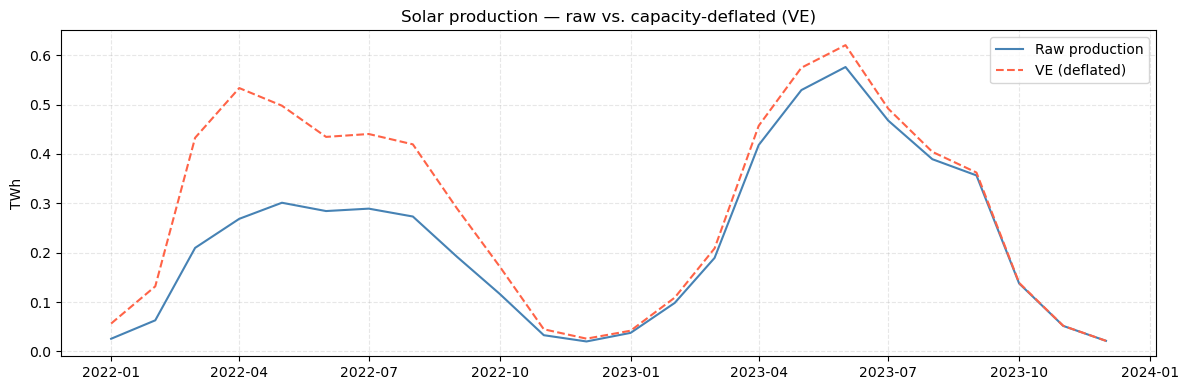

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(monthly["month"], monthly["raw_MWh"]/1e6,  label="Raw production",  color="steelblue", linewidth=1.5)
ax.plot(monthly["month"], monthly["ve_MWh"]/1e6,   label="VE (deflated)",   color="tomato",    linewidth=1.5, linestyle="--")

ax.set_ylabel("TWh")
ax.set_title("Solar production — raw vs. capacity-deflated (VE)")
ax.legend()
ax.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

---

## Example: Wind VE with counterfactual capacity

`value_columns` accepts multiple columns — they are summed before deflation. Here we combine onshore and offshore wind.

Passing `cap_ref=1000` sets the index denominator to 1 GW regardless of actual installed capacity, answering: *what would wind production look like normalised to 1 GW of capacity?*

In [11]:
wind_ve = VE(
    value_columns = ["OnshoreWindMWh", "OffshoreWindMWh"],
    cap_column    = ["WindPowerCapacity"],
    col_name      = "wind_VE",
    start         = 2023,
    end           = 2026,
    cap_ref       = 1_000,   # normalise to 1 GW
    cache         = True,
)

wind_ve.head()


Index denominator is: ===================

  OffshoreWindCapacity: 1000  (counterfactual)


,HourUTC,month,value,wind_VE_idx,wind_VE
0,2023-01-01 00:00:00,2023-01-01,1281.752159,2.3031,556.533437
1,2023-01-01 01:00:00,2023-01-01,1112.529130,2.3031,483.057240
2,2023-01-01 02:00:00,2023-01-01,1022.699637,2.3031,444.053509
3,2023-01-01 03:00:00,2023-01-01,829.812467,2.3031,360.302404
4,2023-01-01 04:00:00,2023-01-01,844.498844,2.3031,366.679191
